
# Pipeline Completo de Clasificación de UAVs con YOLOv8x-cls

Este notebook proporciona un pipeline integral para la clasificación automática de imágenes de UAVs utilizando el modelo YOLOv8x-cls. Incluye la integración con Google Drive para la gestión del dataset, un proceso de entrenamiento robusto, y una evaluación de desempeño detallada con métricas clave para comparativa de desempeño con otros algoritmos (Accuracy, Precisión, Recall, F1-Score y Especificidad), así como visualizaciones esenciales como la Matriz de Confusión y los gráficos de entrenamiento.

## Contenido del Notebook:
1.  **Configuración Inicial:** Montaje de Google Drive, preparación del entorno y definición de rutas.
2.  **Preparación del Dataset:** Carga y organización de imágenes para el entrenamiento de clasificación.
3.  **Entrenamiento del Modelo YOLOv8x-cls:** Carga del modelo, configuración de parámetros y ejecución del entrenamiento.
4.  **Evaluación de Desempeño:** Extracción y visualización de métricas de desempeño (Accuracy, Precisión, Recall, F1-Score, Especificidad) y Matriz de Confusión.
5.  **Test del Modelo:** Realización de inferencias en el conjunto de prueba y visualización de resultados.

## Instrucciones para el Usuario:
*   **Ejecutar en Google Colab:** Este notebook está optimizado para Google Colab. Asegúrate de tener una GPU activa (Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> Acelerador de hardware: GPU).
*   **Dataset en Google Drive:** Sigue las instrucciones en la Sección 1.2 para subir y organizar tu dataset en Google Drive.


### 1.1. Importar Librerías Necesarias


In [5]:
!pip install ultralytics

import os
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ultralytics import YOLO
from IPython.display import Image, display
from sklearn.metrics import classification_report, confusion_matrix

print("Librerías cargadas exitosamente.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Librerías cargadas exitosamente.



### 1.2. Montar Google Drive

Para acceder a tu dataset, primero debes montar tu Google Drive. Esto permitirá que el notebook lea y escriba archivos directamente en tu Drive.

**Pasos:**
1.  Ejecuta la siguiente celda.
2.  Se te pedirá que autorices a Google Colab a acceder a tu Google Drive. Sigue el enlace, selecciona tu cuenta de Google y permite los permisos.
3.  Verás la confirmación "Mounted at /content/drive".


In [2]:

from google.colab import drive
drive.mount("/content/drive")

# Define la ruta base de tu dataset en Google Drive
# Asegúrate de que esta ruta apunte a la carpeta principal de tu dataset en Drive
# Ejemplo: Si tu dataset está en "Mi Drive/UAV_Dataset", la ruta sería
# drive_dataset_path = '/content/drive/MyDrive/UAV_Dataset'

drive_dataset_path = '/content/drive/MyDrive/UAV_Dataset' # ¡AJUSTA ESTA RUTA!
local_dataset_path = './uav_dataset'

print(f"Ruta del dataset en Drive: {drive_dataset_path}")
print(f"Ruta local del dataset: {local_dataset_path}")


Mounted at /content/drive
Ruta del dataset en Drive: /content/drive/MyDrive/UAV_Dataset
Ruta local del dataset: ./uav_dataset



### 1.3. Copiar Dataset de Google Drive al Entorno Local

Para un acceso más rápido durante el entrenamiento, es recomendable copiar el dataset de Google Drive al entorno de ejecución local de Colab. Esto puede tardar unos minutos dependiendo del tamaño de tu dataset.

**Estructura esperada del dataset en Google Drive:**
```
UAV_Dataset/
├── train/
│   ├── ala_fija_001.jpg
│   ├── helicoptero_001.jpg
│   └── ...
├── val/
│   ├── ala_fija_002.jpg
│   └── ...
└── test/
    ├── multi_rotor_001.jpg
    └── ...
```


In [6]:

if os.path.exists(local_dataset_path):
    shutil.rmtree(local_dataset_path) # Limpiar si ya existe

print(f"Copiando dataset de {drive_dataset_path} a {local_dataset_path}...")
shutil.copytree(drive_dataset_path, local_dataset_path)
print("Copia completada.")

# Definir nombres de clases (asegúrate de que coincidan con tus carpetas)
class_names = [d for d in os.listdir(os.path.join(local_dataset_path, 'train')) if os.path.isdir(os.path.join(local_dataset_path, 'train', d))]
class_names.sort() # Asegurar un orden consistente
print(f"Clases detectadas: {class_names}")


Copiando dataset de /content/drive/MyDrive/UAV_Dataset a ./uav_dataset...
Copia completada.
Clases detectadas: ['ala_fija', 'helicoptero', 'multirotor', 'no_uav']



## 2. Preparación del Dataset: Organización por Clase

Para la clasificación de imágenes con YOLOv8-cls, el modelo espera que las imágenes estén organizadas en subcarpetas, donde el nombre de cada subcarpeta representa la clase de las imágenes que contiene. Si tus imágenes aún no están organizadas de esta manera (por ejemplo, si están todas en una sola carpeta `train/` con la clase en el nombre del archivo), el siguiente script las reorganizará automáticamente.

**Ejemplo:** `train/ala_fija_001.jpg` se moverá a `train/ala_fija/ala_fija_001.jpg`.


In [7]:

def organizar_por_clase(base_path):
    splits = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    for split in splits:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path): continue

        # Obtener todas las imágenes antes de mover
        all_images_in_split = [f for f in os.listdir(split_path) if os.path.isfile(os.path.join(split_path, f)) and f.lower().endswith((".jpg", ".jpeg", ".png"))]

        if not all_images_in_split:
            print(f"Aviso: No se encontraron imágenes directamente en {split_path}. Asumiendo que ya están organizadas por clase.")
            continue

        print(f"Organizando carpeta '{split}'...")

        # Crear subcarpetas para cada clase si no existen
        for clase in class_names:
            os.makedirs(os.path.join(split_path, clase), exist_ok=True)

        # Mover archivos basados en su nombre
        for filename in all_images_in_split:
            file_path = os.path.join(split_path, filename)

            found_class = False
            for clase in class_names:
                if clase.lower() in filename.lower(): # Coincidencia insensible a mayúsculas/minúsculas
                    shutil.move(file_path, os.path.join(split_path, clase, filename))
                    found_class = True
                    break
            if not found_class:
                print(f"Advertencia: No se pudo determinar la clase para {filename}. Se dejará en la carpeta original.")
        print(f"✅ Carpeta '{split}' organizada por clases.")

# Ejecuta la función (ajusta la ruta si es necesario)
organizar_por_clase(local_dataset_path)


Aviso: No se encontraron imágenes directamente en ./uav_dataset/test. Asumiendo que ya están organizadas por clase.
Aviso: No se encontraron imágenes directamente en ./uav_dataset/.ipynb_checkpoints. Asumiendo que ya están organizadas por clase.
Aviso: No se encontraron imágenes directamente en ./uav_dataset/train. Asumiendo que ya están organizadas por clase.
Aviso: No se encontraron imágenes directamente en ./uav_dataset/val. Asumiendo que ya están organizadas por clase.



## 3. Entrenamiento del Modelo YOLOv8x-cls

Ahora que el dataset está preparado, cargaremos el modelo pre-entrenado `yolov8x-cls.pt` y lo entrenaremos con nuestras imágenes de UAVs. Este modelo está optimizado para tareas de clasificación de imágenes.

**Consideraciones:**
*   **`epochs`:** Número de veces que el modelo verá todo el dataset. Para resultados académicos, se recomiendan 50-100+.
*   **`imgsz`:** Tamaño de la imagen de entrada. 224 es un valor común para clasificación.
*   **`batch`:** Número de imágenes procesadas simultáneamente. Ajusta según la memoria de tu GPU.
*   **`name`:** Nombre del experimento, los resultados se guardarán en `runs/classify/<name>`.


In [8]:

# Cargar modelo de CLASIFICACIÓN
model = YOLO('yolov8x-cls.pt')

# Entrenar el modelo
# Asegúrate de que 'data' apunte a la carpeta base del dataset local (ej. './uav_dataset')
results_train = model.train(
    data=local_dataset_path,
    epochs=20, # Ajusta según tus necesidades y tiempo disponible
    imgsz=224, # Tamaño estándar para clasificación
    batch=32,  # Ajusta según la memoria de tu GPU
    name='uav_classification_yolov8x_cls',
    project='runs_uav_cls',
    plots=True # Genera automáticamente gráficos de entrenamiento
)

print("Entrenamiento completado. Resultados guardados en runs_uav_cls/uav_classification_yolov8x_cls")


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./uav_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=uav_classification_yolov8x_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 


## 4. Evaluación de Desempeño: Métricas de desempeño y visualizaciones

Aquí extraemos y visualizamos métricas detalladas que te permitirán comparar el rendimiento de YOLOv8x-cls con otros algoritmos (AdaBoost, CNN). Incluiremos Accuracy, Precisión, Recall, F1-Score y Especificidad, tanto a nivel global como por clase, además de la Matriz de Confusión y los gráficos de entrenamiento.


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/uav_dataset/train... found 700 images in 4 classes ✅ 
val: /content/uav_dataset/val... found 152 images in 4 classes ✅ 
test: /content/uav_dataset/test... found 148 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 721.7±706.0 MB/s, size: 56.3 KB)
val: Scanning /content/uav_dataset/val... 152 images, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 49.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 10/10 2.4it/s 4.1s
                   all      0.888          1
Speed: 0.4ms preprocess, 5.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-5

📊 MÉTRICAS GLOBALES DE CLASIFICACIÓN:
Exactitud (Accuracy) Top-1: 0.8882
Exactitud Top-5: 1.0000

📋 TABLA COMPARATIVA DE MÉTRICAS DE DESEMPEÑO:


,precision,recall,f1-score,support,Especificidad
ala_fija,0.8333,0.921053,0.875,38.0,0.938596
helicoptero,0.8571,0.947368,0.9,38.0,0.947368
multirotor,0.9444,0.894737,0.918919,38.0,0.982456
no_uav,0.9375,0.789474,0.857143,38.0,0.982456
Weighted Avg,0.8931,0.888158,0.887765,152.0,
Global Top-1 Accuracy,0.8882,,,,



🎨 MATRIZ DE CONFUSIÓN (Normalizada): Análisis de Errores por Clase


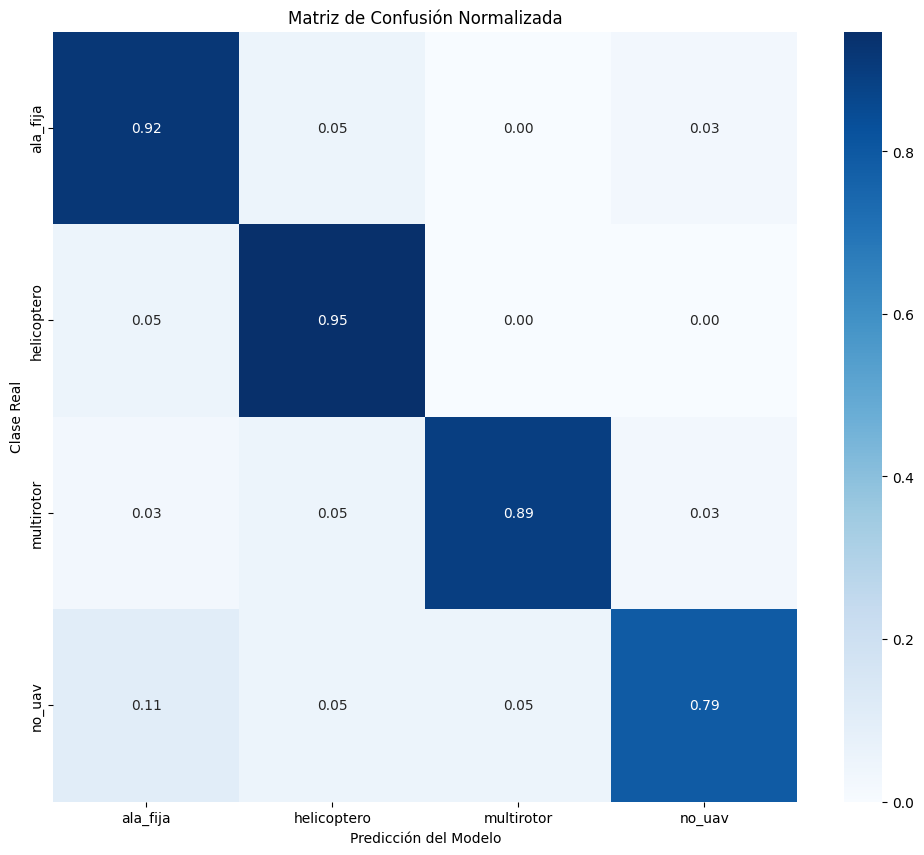


📈 GRÁFICOS DE ENTRENAMIENTO (Pérdida y Métricas por Época):


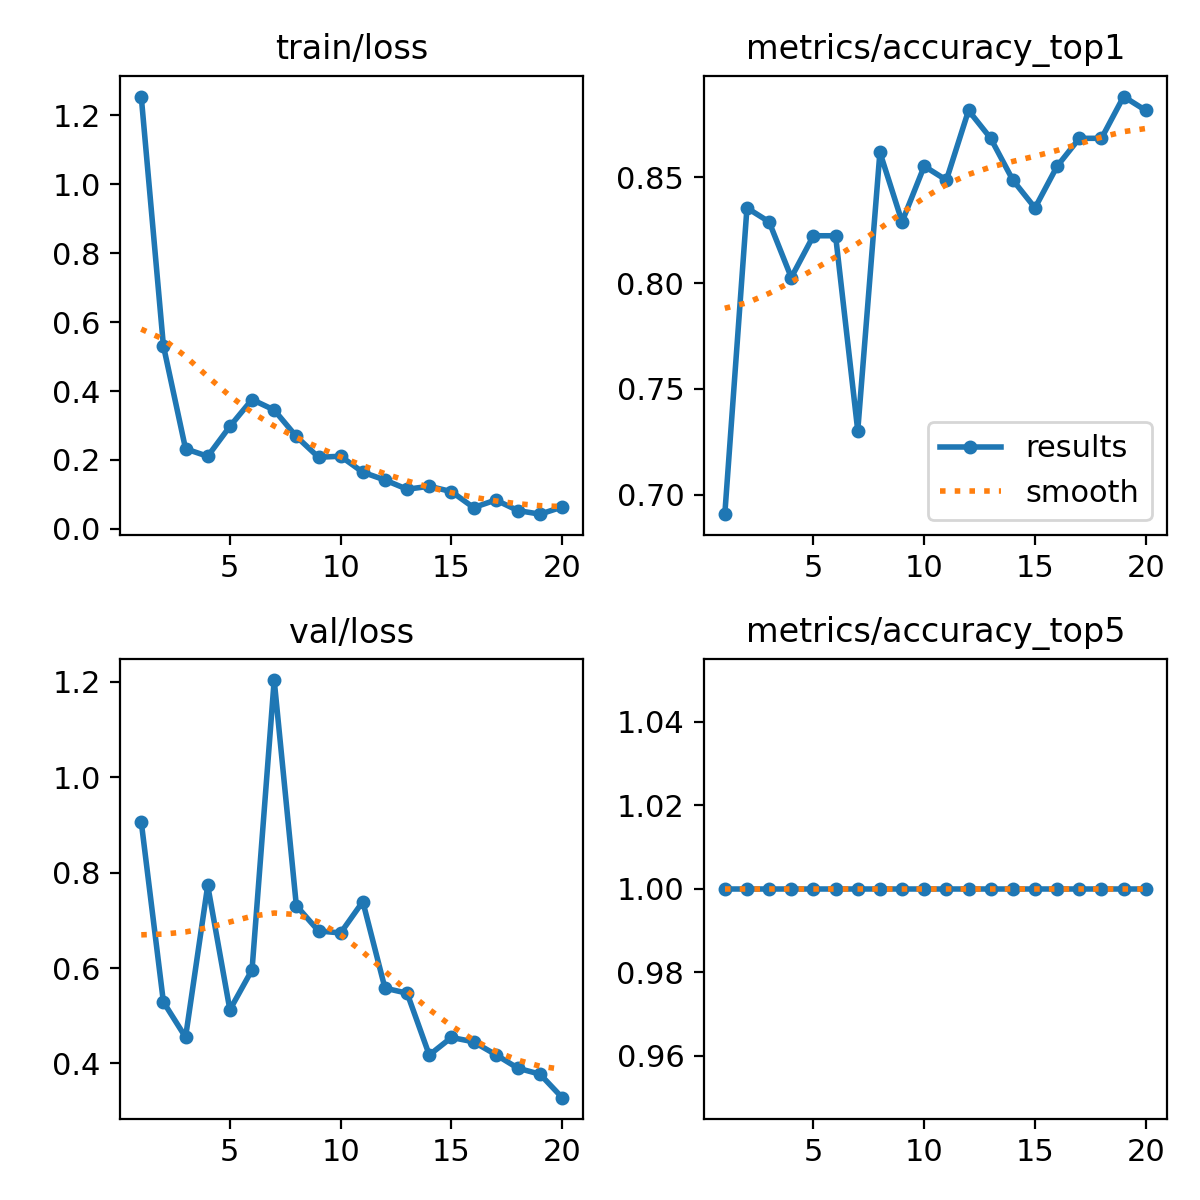

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Ejecutar validación para obtener métricas generales
metrics = model.val()

print("\n📊 MÉTRICAS GLOBALES DE CLASIFICACIÓN:")
print(f"Exactitud (Accuracy) Top-1: {metrics.top1:.4f}")
print(f"Exactitud Top-5: {metrics.top5:.4f}")

# 2. Obtener predicciones y etiquetas reales para el conjunto de validación
# Necesitamos esto para calcular métricas por clase y la especificidad

# Obtener la ruta de la última ejecución de entrenamiento
# YOLOv8 guarda los resultados en runs/classify/project_name/experiment_name
# En este caso, project_name='runs_uav_cls' y experiment_name='uav_classification_yolov8x_cls'
base_yolo_output_dir = os.path.join('runs', 'classify', 'runs_uav_cls')
latest_run_dir = None # Initialize to None

if os.path.exists(base_yolo_output_dir):
    # Listar los directorios dentro del path base que corresponden a las ejecuciones
    # Filtrar por directorios que contengan el nombre del experimento
    run_directories = [d for d in os.listdir(base_yolo_output_dir)
                       if os.path.isdir(os.path.join(base_yolo_output_dir, d)) and 'uav_classification_yolov8x_cls' in d]

    if run_directories:
        # Encontrar la ejecución más reciente basándose en la hora de modificación
        latest_run_name = max(run_directories, key=lambda d: os.path.getmtime(os.path.join(base_yolo_output_dir, d)))
        latest_run_dir = os.path.join(base_yolo_output_dir, latest_run_name)
    else:
        print(f"Advertencia: No se encontraron ejecuciones con 'uav_classification_yolov8x_cls' en '{base_yolo_output_dir}'.")
else:
    print(f"Error: El directorio '{base_yolo_output_dir}' no existe. Asegúrate de que el entrenamiento se haya completado exitosamente.")

if latest_run_dir:
    # Cargar el mejor modelo entrenado para la inferencia
    best_model_path = os.path.join(latest_run_dir, 'weights/best.pt')
    model_for_predict = YOLO(best_model_path)

    val_images_path = os.path.join(local_dataset_path, 'val')

    y_true = []
    y_pred = []

    # Iterar sobre las subcarpetas de clases en el conjunto de validación
    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(val_images_path, class_name)
        if not os.path.exists(class_folder): continue

        for img_file in os.listdir(class_folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(class_folder, img_file)

                # Realizar predicción
                results_predict = model_for_predict.predict(source=img_path, verbose=False)

                if results_predict and results_predict[0].probs is not None:
                    pred_label_idx = results_predict[0].probs.top1
                    y_true.append(class_idx)
                    y_pred.append(pred_label_idx)

    # Asegurarse de que haya datos para calcular las métricas
    if len(y_true) == 0:
        print("No se encontraron imágenes de validación o no se pudieron realizar predicciones.")
    else:
        # 3. Generar Reporte de Clasificación Detallado (Precision, Recall, F1-Score)
        report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
        df_report = pd.DataFrame(report).transpose()

        # 4. Calcular la Especificidad a partir de la matriz de confusión
        cm_raw = confusion_matrix(y_true, y_pred) # Keep raw for specificity calculation
        cm_normalized = confusion_matrix(y_true, y_pred, normalize='true') # Normalized for display

        specificity_scores = []
        for i in range(len(class_names)):
            tn = np.sum(np.delete(np.delete(cm_raw, i, axis=0), i, axis=1)) # True Negatives
            fp = np.sum(cm_raw[:, i]) - cm_raw[i, i] # False Positives
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            specificity_scores.append(specificity)

        df_specificity = pd.DataFrame({"Clase": class_names, "Especificidad": specificity_scores})

        # 5. Consolidar todas las métricas en una sola tabla comparativa
        # Extraer métricas por clase de df_report
        per_class_metrics = df_report.loc[class_names].copy()

        # Añadir la columna de especificidad a las métricas por clase
        specificity_map = df_specificity.set_index('Clase')['Especificidad']
        per_class_metrics['Especificidad'] = per_class_metrics.index.map(specificity_map)

        # Crear filas de resumen para la tabla
        summary_rows = []
        # Añadir la precisión ponderada, recall y f1-score
        summary_rows.append(pd.DataFrame({
            'precision': [df_report.loc['weighted avg', 'precision']],
            'recall': [df_report.loc['weighted avg', 'recall']],
            'f1-score': [df_report.loc['weighted avg', 'f1-score']],
            'support': [df_report.loc['weighted avg', 'support']],
            'Especificidad': [''] # No hay una 'Especificidad' global ponderada estándar aquí
        }, index=['Weighted Avg']))

        # Añadir la Exactitud Global Top-1
        summary_rows.append(pd.DataFrame({
            'precision': [metrics.top1], # Usamos la columna 'precision' para mostrar la Accuracy Global
            'recall': [''],
            'f1-score': [''],
            'support': [''],
            'Especificidad': ['']
        }, index=['Global Top-1 Accuracy']))

        # Concatenar todas las partes para formar la tabla final
        final_metrics_df = pd.concat([per_class_metrics] + summary_rows)

        print("\n📋 TABLA COMPARATIVA DE MÉTRICAS DE DESEMPEÑO:")
        display(final_metrics_df.round(4).fillna(''))

        # 6. Matriz de Confusión Visual
        print("\n🎨 MATRIZ DE CONFUSIÓN (Normalizada): Análisis de Errores por Clase")
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Matriz de Confusión Normalizada')
        plt.ylabel('Clase Real')
        plt.xlabel('Predicción del Modelo')
        plt.show()

        # 7. Gráficos de Entrenamiento generados por YOLO
        print("\n📈 GRÁFICOS DE ENTRENAMIENTO (Pérdida y Métricas por Época):")
        results_plot_path = os.path.join(latest_run_dir, 'results.png')
        if os.path.exists(results_plot_path):
            display(Image(filename=results_plot_path))
        else:
            print("No se encontró 'results.png'. Asegúrate de que 'plots=True' en el entrenamiento y que el archivo se generó.")
else:
    print("\nNo se pudo proceder con la evaluación detallada porque no se encontró el directorio de la última ejecución del modelo.")


## 5. Test del Modelo: Inferencia y Visualización de Predicciones

En esta sección, utilizaremos el modelo entrenado para realizar predicciones en el conjunto de test (datos no vistos). Esto nos permite evaluar cómo se comporta el modelo en un escenario real y visualizar algunos ejemplos de sus clasificaciones.


Modelo cargado para test desde: runs/classify/runs_uav_cls/uav_classification_yolov8x_cls/weights/best.pt
Verificando la integridad de las imágenes de test con carga completa...
Advertencia: Imagen corrupta o truncada detectada y omitida: ./uav_dataset/test/helicoptero/helicoptero_100.jpg (image file is truncated (13 bytes not processed))
Se encontraron 147 imágenes válidas de 148 imágenes totales.


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Results saved to /content/runs/classify/runs/classify/runs_uav_cls/uav_classification_yolov8x_cls/predict_test

🖼️ VISUALIZACIÓN DE PREDICCIONES EN EL CONJUNTO DE TEST (Primeras 5 imágenes):


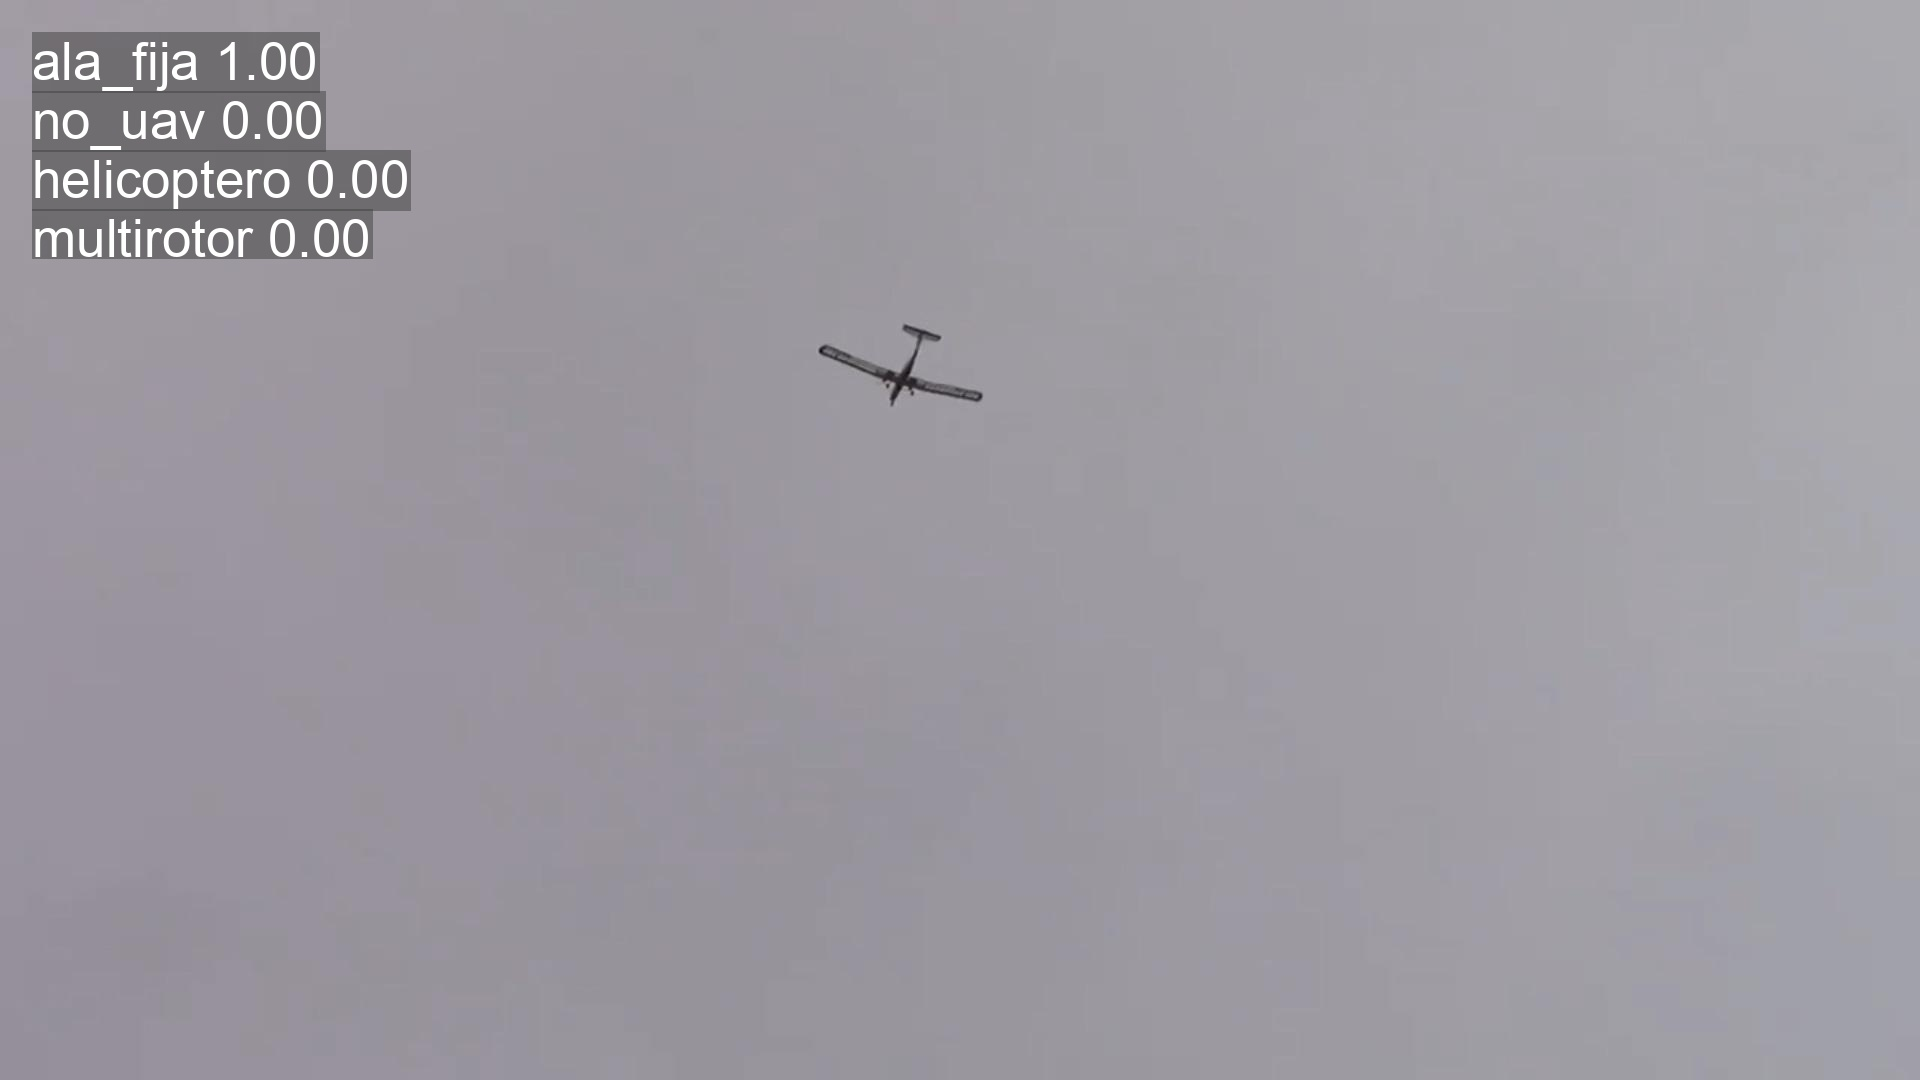

Predicción para image10.jpg


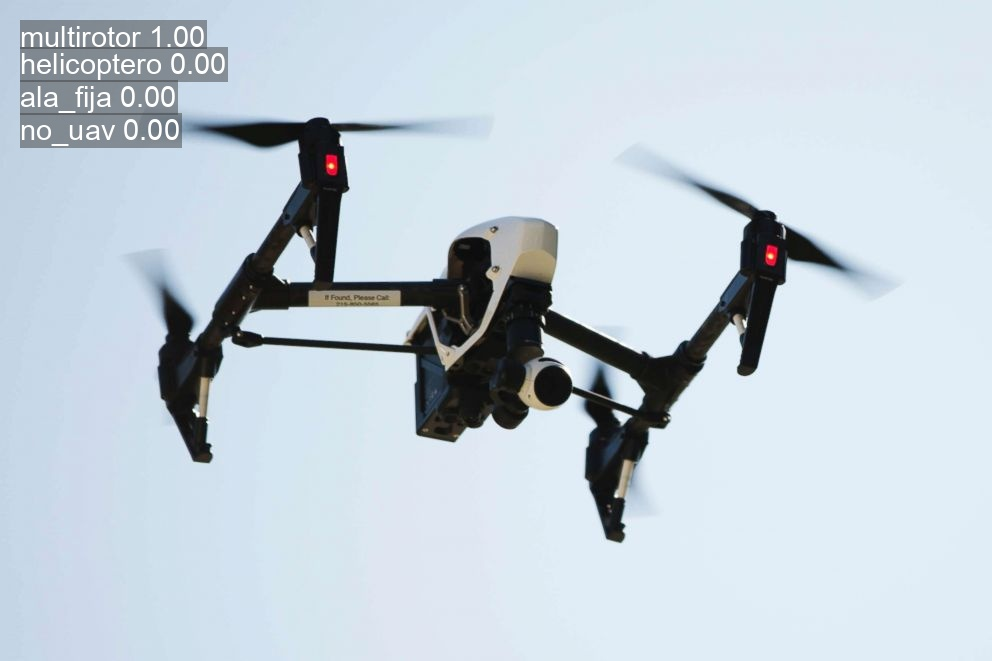

Predicción para image100.jpg


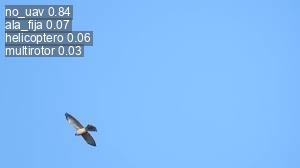

Predicción para image129.jpg


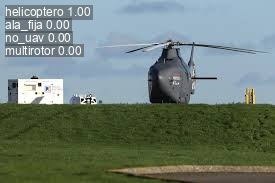

Predicción para image72.jpg


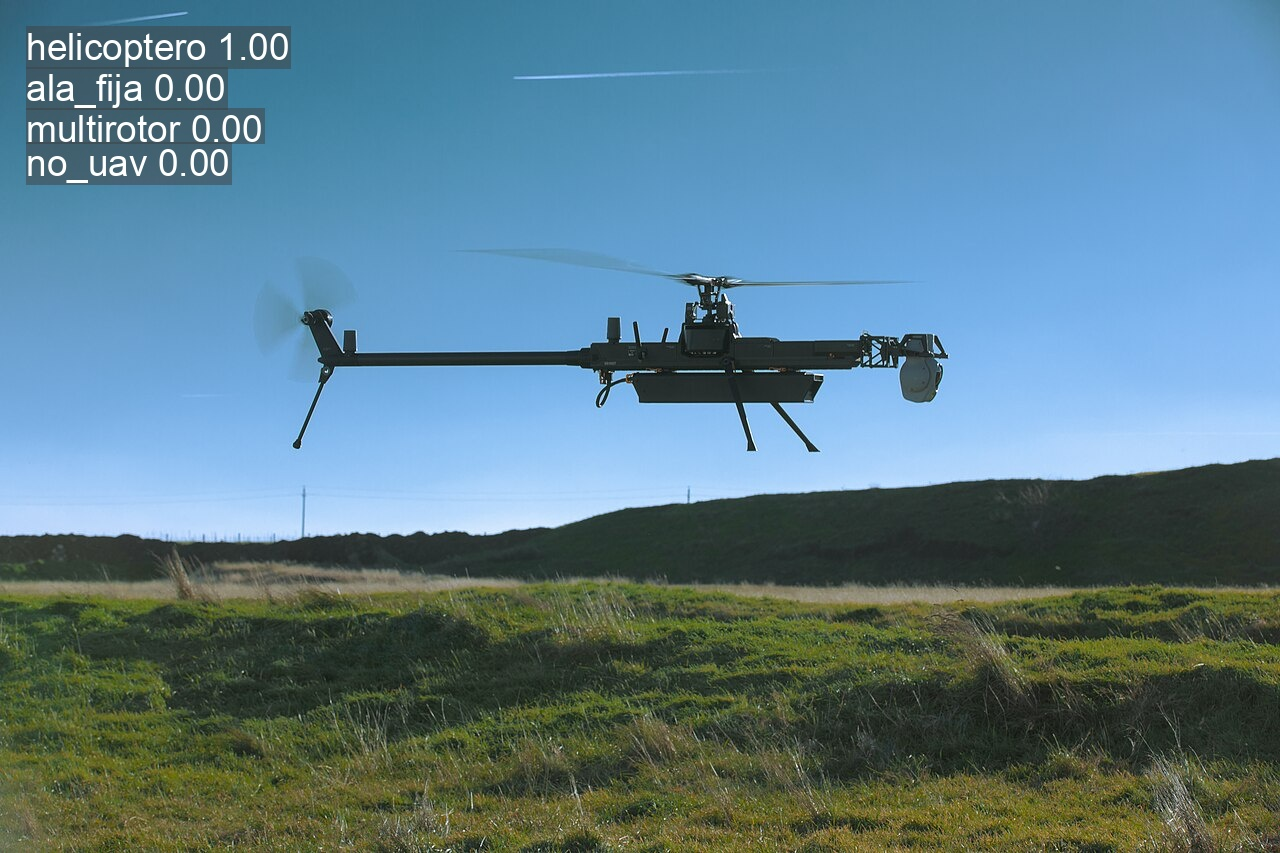

Predicción para image71.jpg


In [18]:
import os
from ultralytics import YOLO
from IPython.display import Image, display
from PIL import Image as PILImage # Import PIL Image to check for corruption

# Cargar el mejor modelo entrenado (si no está ya cargado)
# Asegúrate de que 'latest_run_dir' esté definido de la sección anterior
if 'latest_run_dir' not in locals() or not os.path.exists(latest_run_dir):
    # Si la celda anterior no se ejecutó, buscar la última ejecución
    base_runs = 'runs_uav_cls'
    if os.path.exists(base_runs):
        runs = [os.path.join(base_runs, d) for d in os.listdir(base_runs) if 'uav_classification_yolov8x_cls' in d]
        latest_run_dir = max(runs, key=os.path.getmtime) if runs else None

if latest_run_dir:
    best_model_path = os.path.join(latest_run_dir, 'weights/best.pt')
    model_for_test = YOLO(best_model_path)
    print(f"Modelo cargado para test desde: {best_model_path}")

    test_images_path = os.path.join(local_dataset_path, 'test')
    all_test_image_paths = []
    valid_test_image_paths = []

    # Recopilar todas las rutas de imágenes del conjunto de test de las subcarpetas de clases
    for class_name in class_names:
        class_folder = os.path.join(test_images_path, class_name)
        if os.path.exists(class_folder) and os.path.isdir(class_folder):
            for img_file in os.listdir(class_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_test_image_paths.append(os.path.join(class_folder, img_file))

    # Filtrar imágenes corruptas usando una carga completa
    if all_test_image_paths:
        print("Verificando la integridad de las imágenes de test con carga completa...")
        for img_path in all_test_image_paths:
            try:
                with PILImage.open(img_path) as img:
                    img.load() # Attempt a full load to catch truncation errors
                valid_test_image_paths.append(img_path)
            except (IOError, SyntaxError, OSError) as e:
                print(f"Advertencia: Imagen corrupta o truncada detectada y omitida: {img_path} ({e})")
        print(f"Se encontraron {len(valid_test_image_paths)} imágenes válidas de {len(all_test_image_paths)} imágenes totales.")

    if not valid_test_image_paths:
        print(f"Error: No se encontraron imágenes válidas en las subcarpetas de {test_images_path}. Asegúrate de que las imágenes de test estén organizadas por clase y que existan y no estén corruptas.")
    else:
        # Realizar predicciones en el conjunto de test
        # Guardar los resultados visuales en una carpeta 'predict_test' para distinguirlos del entrenamiento
        # Setting project to 'runs/classify' and name to 'runs_uav_cls/uav_classification_yolov8x_cls/predict_test'
        # ensures a consistent path under 'runs/classify/' without double nesting.
        base_project_dir = os.path.join('runs', 'classify')
        run_sub_dir = os.path.relpath(latest_run_dir, start=base_project_dir) # Get relative path for name
        prediction_output_name = os.path.join(run_sub_dir, 'predict_test')

        test_predict_results = model_for_test.predict(source=valid_test_image_paths, save=True, project=base_project_dir, name=prediction_output_name, verbose=False)

        # Get the actual save directory from the results object
        if test_predict_results and hasattr(test_predict_results[0], 'save_dir'):
            predict_output_dir = test_predict_results[0].save_dir
        else:
            # Fallback if save_dir is not directly available, though it should be
            predict_output_dir = os.path.join(base_project_dir, prediction_output_name)

        print("\n🖼️ VISUALIZACIÓN DE PREDICCIONES EN EL CONJUNTO DE TEST (Primeras 5 imágenes):")

        if os.path.exists(predict_output_dir):
            predicted_images = [f for f in os.listdir(predict_output_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            for i, img_file in enumerate(predicted_images):
                if i >= 5: break # Mostrar solo las primeras 5
                img_path = os.path.join(predict_output_dir, img_file)
                display(Image(filename=img_path, width=400))
                print(f"Predicción para {img_file}")
        else:
            print(f"No se encontraron imágenes predichas en '{predict_output_dir}'. Asegúrate de que el directorio de test contenga imágenes y que el guardado fue exitoso.")
else:
    print("No se pudo cargar el modelo para la fase de test. Asegúrate de que el entrenamiento se haya completado.")